---
## SECCIÓN 1 — Instalación de Librerías

Instalamos todas las dependencias necesarias para el proyecto. En Google Colab la mayoría ya vienen preinstaladas, pero `shap` y `openpyxl` requieren instalación explícita.

| Librería | Uso |
|----------|-----|
| `scikit-learn` | Modelo Random Forest, métricas, validación cruzada |
| `pandas` / `numpy` | Manipulación de datos |
| `matplotlib` / `seaborn` | Visualizaciones estáticas |
| `plotly` | Gráficos interactivos |
| `shap` | Explicabilidad del modelo (SHAP values) |
| `joblib` | Serialización del modelo entrenado |

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn plotly openpyxl shap joblib -q
print(' Librerías instaladas correctamente')

 Librerías instaladas correctamente



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\elvis\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


 SECCIÓN 2 — Importación de Librerías

Importamos todos los módulos organizados por categoría:
- **Datos:** `pandas`, `numpy`
- **Visualización:** `matplotlib`, `seaborn`, `plotly`
- **Modelado:** `sklearn` (Random Forest, métricas, validación, tuning)
- **Explicabilidad:** `shap`

In [ ]:
# ── Datos ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import math
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Preprocesamiento ───────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ── Modelo principal ───────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ── Validación y métricas ──────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

# ── Explicabilidad ─────────────────────────────────────────
import shap

# ── Persistencia del modelo ────────────────────────────────
import joblib

print(' Todas las librerías importadas correctamente')
print(f'   pandas   {pd.__version__}')
print(f'   numpy    {np.__version__}')
print(f'   sklearn  importado')
print(f'   shap     {shap.__version__}')

---
## SECCIÓN 3 — Carga de Datos CSV

Cargamos los  archivos CSV 



In [ ]:

# ══════════════════════════════════════════════════════════
# OPCIÓN C — Archivos ya en el entorno actual (default)
# ══════════════════════════════════════════════════════════
BASE = 'data/'  # cambia si están en un subdirectorio

# ── Carga de tablas ────────────────────────────────────────
pedidos       = pd.read_csv(BASE + 'pedidos.csv',        parse_dates=['fecha', 'fecha_creacion'])
detalles      = pd.read_csv(BASE + 'pedido_detalles.csv')
productos     = pd.read_csv(BASE + 'productos.csv')
tipos         = pd.read_csv(BASE + 'tipos_productos.csv')
bobinas       = pd.read_csv(BASE + 'bobinas.csv',        parse_dates=['fecha_creacion'])
lotes         = pd.read_csv(BASE + 'lotes.csv',          parse_dates=['fecha_ingreso', 'fecha_creacion'])
proveedores   = pd.read_csv(BASE + 'proveedores.csv')
precios_metro = pd.read_csv(BASE + 'precios_metro.csv')

print(f'   pedidos          → {len(pedidos):>5} registros')
print(f'   pedido_detalles  → {len(detalles):>5} registros')
print(f'   productos        → {len(productos):>5} registros')
print(f'   tipos_productos  → {len(tipos):>5} registros')
print(f'   bobinas          → {len(bobinas):>5} registros')
print(f'   lotes            → {len(lotes):>5} registros')
print(f'   proveedores      → {len(proveedores):>5} registros')
print(f'   precios_metro    → {len(precios_metro):>5} registros')

   pedidos          →   679 registros
   pedido_detalles  →  1633 registros
   productos        →    20 registros
   tipos_productos  →     5 registros
   bobinas          →   117 registros
   lotes            →    67 registros
   proveedores      →     4 registros
   precios_metro    →    10 registros


---
## SECCION 4 — Construccion del Dataset Maestro

Realizamos la union de tablas y generamos un dataset con las variables relevantes. Los datos son agrupados a nivel mensual por tipo de calamina, de forma que el modelo pueda identificar tendencias y patrones estacionales reales en la demanda total.


In [ ]:
# ── JOIN de tablas y construccion del dataset agrupado mensual ──

# 1. Unir detalles con pedidos para obtener la fecha
df = detalles.merge(pedidos[['id_pedido', 'fecha', 'estado_pedido']], on='id_pedido')

# 2. Filtrar pedidos cancelados
df = df[df['estado_pedido'] != 'cancelado'].copy()

# 3. Unir con productos y tipos
df = df.merge(productos[['id_producto', 'id_tipo_producto']], on='id_producto')
df = df.merge(tipos[['id_tipo_producto', 'nombre']].rename(columns={'nombre': 'tipo_calamina'}), on='id_tipo_producto')

# 4. Convertir cantidad a numero
df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce').fillna(0).astype(int)

# 5. Extraer variables temporales
df['fecha'] = pd.to_datetime(df['fecha'])
df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month

# 6. AGREGAR A NIVEL MENSUAL POR TIPO DE CALAMINA
df_mensual = (
    df.groupby(['anio', 'mes', 'tipo_calamina'])['cantidad']
    .sum()
    .reset_index()
    .rename(columns={'cantidad': 'demanda_total'})
    .sort_values(['tipo_calamina', 'anio', 'mes'])
)

# 7. Agregar variable de temporada
df_mensual['temporada'] = df_mensual['mes'].apply(
    lambda m: 'Alta' if 4 <= m <= 10 else 'Baja'
)

# 8. Agregar lags (memoria historica: cuanto se vendio meses anteriores)
for lag in [1, 2, 3]:
    df_mensual[f'lag_{lag}'] = (
        df_mensual.groupby('tipo_calamina')['demanda_total'].shift(lag)
    )
z
# 9. Media movil de los ultimos 3 meses
df_mensual['media_movil_3'] = (
    df_mensual.groupby('tipo_calamina')['demanda_total']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# 10. Eliminar filas sin datos de lag (primeros meses de cada tipo)
df_modelo = df_mensual.dropna().copy()

print(f"Dataset mensual construido: {len(df_modelo)} registros")
print(f"Tipos de calamina: {df_modelo['tipo_calamina'].nunique()}")
print(f"Rango: {df_modelo['anio'].min()}-{df_modelo['anio'].max()}")
df_modelo.head(10)


Dataset mensual construido: 158 registros
Tipos de calamina: 5
Rango: 2023-2025


,anio,mes,tipo_calamina,demanda_total,temporada,lag_1,lag_2,lag_3,media_movil_3
14,2023,4,Calamina Ondulada,320,Alta,70.0,5.0,170.0,81.666667
19,2023,5,Calamina Ondulada,250,Alta,320.0,70.0,5.0,131.666667
23,2023,6,Calamina Ondulada,215,Alta,250.0,320.0,70.0,213.333333
28,2023,7,Calamina Ondulada,60,Alta,215.0,250.0,320.0,261.666667
33,2023,8,Calamina Ondulada,305,Alta,60.0,215.0,250.0,175.000000
38,2023,9,Calamina Ondulada,390,Alta,305.0,60.0,215.0,193.333333
43,2023,10,Calamina Ondulada,135,Alta,390.0,305.0,60.0,251.666667
47,2023,11,Calamina Ondulada,135,Baja,135.0,390.0,305.0,276.666667
51,2023,12,Calamina Ondulada,85,Baja,135.0,135.0,390.0,220.000000
56,2024,1,Calamina Ondulada,80,Baja,85.0,135.0,135.0,118.333333


---
## SECCION 5 — Preprocesamiento de Datos y Division del Dataset

Conversion de variables categoricas a formato numerico y division cronologica del dataset en conjuntos de entrenamiento y prueba.

### Variables de entrada al modelo
| Variable | Descripcion |
|----------|-------------|
| anio | Ano del registro |
| mes | Mes del registro (1-12) |
| temporada | Indicador de temporada alta o baja |
| tipo_calamina | Familia de producto |
| lag_1, lag_2, lag_3 | Demanda total de los 1, 2 y 3 meses anteriores |
| media_movil_3 | Promedio de demanda de los ultimos 3 meses |

### Division del Dataset
| Conjunto | Descripcion |
|----------|-------------|
| Entrenamiento (Train) | Primer 80% de los datos ordenados cronologicamente |
| Prueba (Test) | Ultimo 20% de los datos, reservados para evaluar el modelo |


In [ ]:
# ── PREPROCESAMIENTO Y DIVISION DEL DATASET ─────────────────
from sklearn.model_selection import train_test_split

# 1. Copiar dataset
df_prep = df_modelo.copy()

# 2. Codificar variables categoricas
df_prep = pd.get_dummies(df_prep, columns=['temporada', 'tipo_calamina'])

# 3. Separar entradas (X) y salida (Y)
X = df_prep.drop(columns=['demanda_total'])
Y = df_prep['demanda_total']

# 4. Division cronologica 80/20
X_entrenamiento, X_prueba, Y_entrenamiento, Y_prueba = train_test_split(
    X, Y, test_size=0.20, shuffle=False
)

print(f"Preprocesamiento y Division Completada")
print(f" {'─'*42}")
print(f" ENTRENAMIENTO (Train) : {X_entrenamiento.shape[0]} registros")
print(f" PRUEBA (Test)         : {X_prueba.shape[0]} registros")
print(f" {'─'*42}")
print(f"Variables de entrada: {list(X.columns)}")


Preprocesamiento y Division Completada
 ──────────────────────────────────────────
 ENTRENAMIENTO (Train) : 126 registros
 PRUEBA (Test)         : 32 registros
 ──────────────────────────────────────────
Variables de entrada: ['anio', 'mes', 'lag_1', 'lag_2', 'lag_3', 'media_movil_3', 'temporada_Alta', 'temporada_Baja', 'tipo_calamina_Calamina Ondulada', 'tipo_calamina_Calamina Prepintada', 'tipo_calamina_Calamina Teja', 'tipo_calamina_Calamina Trapezoidal', 'tipo_calamina_Plancha Lisa / Techo Plano']


---
## SECCION 6 — Entrenamiento del Modelo Random Forest

Desarrollo del modelo predictivo utilizando el algoritmo de Machine Learning de Random Forest Regressor. En esta etapa el modelo procesa los datos numericos del preprocesamiento para encontrar patrones matematicos en la demanda.

### Ajuste de Hiperparametros
Para optimizar el aprendizaje, capturar la tendencia adecuadamente y evitar el sobreajuste (overfitting), el modelo se inicializa con la siguiente configuracion:
- n_estimators = 200: Cantidad de arboles de decision individuales matematicos que conforman el ensamble.
- max_depth = 10: Profundidad maxima de cada arbol, limitando que el modelo trate de memorizar los datos crudos.
- min_samples_split = 5: Minimo de registros estadisticos requeridos para seguir subdividiendo los datos.
- min_samples_leaf = 2: Minimo volumen de datos permitidos en las ramas o estimaciones finales.


In [ ]:
# ── ENTRENAMIENTO DEL MODELO PREDICTIVO (RANDOM FOREST) ─────

# Importamos exclusivamente el modelo requerido
from sklearn.ensemble import RandomForestRegressor
import time

print("Iniciando entrenamiento del modelo...")
tiempo_inicio = time.time()

# 1. Instanciacion del modelo y configuracion de hiperparametros
modelo_rf = RandomForestRegressor(
    n_estimators=200,          
    max_depth=10,              
    min_samples_split=5,       
    min_samples_leaf=2,        
    random_state=42,           # Mantiene los resultados constantes
    n_jobs=-1                  # Utiliza toda la potencia del procesador
)

# 2. Alimentacion y Entrenamiento del algoritmo (FIT)
# Le entregamos las entradas (X) para que aprenda a adivinar las salidas (Y)
modelo_rf.fit(X_entrenamiento, Y_entrenamiento)

tiempo_fin = time.time()

# 3. Ejecucion de Predicciones
# Predicciones internas (Para evaluar si realmente aprendio del historico)
predicciones_train = modelo_rf.predict(X_entrenamiento)

# Predicciones externas o futuras (Para evaluar como reacciona a los datos nuevos del Test)
predicciones_test = modelo_rf.predict(X_prueba)

print(f"Entrenamiento completado exitosamente en {tiempo_fin - tiempo_inicio:.2f} segundos.")
print("El modelo ha sido alimentado y las proyecciones de prueba estan listas para ser evaluadas.")


Iniciando entrenamiento del modelo...
Entrenamiento completado exitosamente en 0.20 segundos.
El modelo ha sido alimentado y las proyecciones de prueba estan listas para ser evaluadas.


---
## SECCION 7 — Evaluacion del Desempeño del Modelo

Desarrollo y calculo de las metricas estadisticas fundamentales para medir el margen de error y la precision del algoritmo predictivo sobre los conjuntos de datos.

### Metricas Evaluadas
- MAE (Mean Absolute Error): Cuantifica la diferencia promedio absoluta entre las estimaciones del modelo y la demanda real. Su valor se encuentra expresado en las mismas unidades del dataset (unidades fisicas solicitadas).
- RMSE (Root Mean Squared Error): Raiz del error cuadratico medio. Agrega una fuerte penalizacion sobre aquellas estimaciones con desviaciones matematicas extremas.
- R² (Coeficiente de Determinacion): Refleja la fraccion de la variabilidad o el movimiento en la demanda real que el modelo logra explicar y proyectar con exito.


In [ ]:
# ── CARGA DE METRICAS Y EVALUACION ESTADISTICA ─────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Calculo de metricas para el conjunto de Datos de Entrenamiento
mae_train = mean_absolute_error(Y_entrenamiento, predicciones_train)
rmse_train = np.sqrt(mean_squared_error(Y_entrenamiento, predicciones_train))
r2_train = r2_score(Y_entrenamiento, predicciones_train)

# 2. Calculo de metricas para el conjunto de Datos de Prueba (Test reales)
mae_test = mean_absolute_error(Y_prueba, predicciones_test)
rmse_test = np.sqrt(mean_squared_error(Y_prueba, predicciones_test))
r2_test = r2_score(Y_prueba, predicciones_test)

# 3. Presentacion formal de los niveles de error y exactitud
print("METRICAS DE DESEMPEÑO — PREDICCION DE DEMANDA")
print("=" * 55)

print("[ EVALUACION INTERNA : DATOS DE ENTRENAMIENTO ]")
print(f" MAE  : {mae_train:.2f} unidades en promedio de equivocacion")
print(f" RMSE : {rmse_train:.2f} unidades (Penalizacion por picos)")
print(f" R²   : {r2_train:.3f} resuelto sobre 1.000")
print("-" * 55)

print("[ EVALUACION EXTERNA : DATOS DE PRUEBA (ESCENARIO DESCONOCIDO) ]")
print(f" MAE  : {mae_test:.2f} unidades en promedio de equivocacion")
print(f" RMSE : {rmse_test:.2f} unidades (Penalizacion por picos)")
print(f" R²   : {r2_test:.3f} resuelto sobre 1.000")
print("=" * 55)


METRICAS DE DESEMPEÑO — PREDICCION DE DEMANDA
[ EVALUACION INTERNA : DATOS DE ENTRENAMIENTO ]
 MAE  : 47.31 unidades en promedio de equivocacion
 RMSE : 66.57 unidades (Penalizacion por picos)
 R²   : 0.940 resuelto sobre 1.000
-------------------------------------------------------
[ EVALUACION EXTERNA : DATOS DE PRUEBA (ESCENARIO DESCONOCIDO) ]
 MAE  : 92.00 unidades en promedio de equivocacion
 RMSE : 103.74 unidades (Penalizacion por picos)
 R²   : 0.798 resuelto sobre 1.000


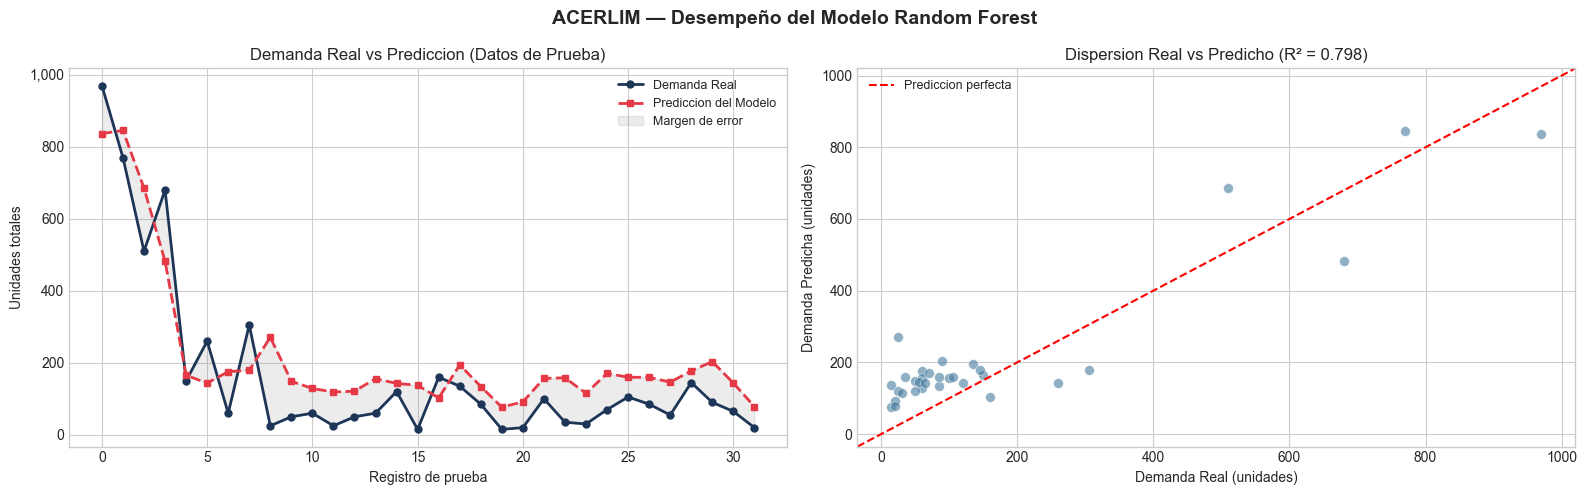

Grafico de desempeño guardado como: grafico_desempeno_modelo.png


In [ ]:
# ── GRAFICOS DE DESEMPEÑO DEL MODELO ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ACERLIM — Desempeño del Modelo Random Forest',
             fontsize=14, fontweight='bold')

# ── GRAFICO 1: Real vs Predicho (lineas) ────────────────────
axes[0].plot(range(len(Y_prueba)), Y_prueba.values,
             marker='o', label='Demanda Real', color='#1D3557',
             linewidth=2, markersize=5)
axes[0].plot(range(len(Y_prueba)), predicciones_test,
             marker='s', label='Prediccion del Modelo', color='#E63946',
             linewidth=2, linestyle='--', markersize=5)
axes[0].fill_between(range(len(Y_prueba)),
                     Y_prueba.values, predicciones_test,
                     alpha=0.15, color='gray', label='Margen de error')
axes[0].set_title('Demanda Real vs Prediccion (Datos de Prueba)')
axes[0].set_xlabel('Registro de prueba')
axes[0].set_ylabel('Unidades totales')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── GRAFICO 2: Scatter Real vs Predicho ─────────────────────
axes[1].scatter(Y_prueba, predicciones_test, alpha=0.6,
                color='#457B9D', s=50, edgecolors='white', linewidth=0.5)

# Linea diagonal de prediccion perfecta
lim_min = min(Y_prueba.min(), predicciones_test.min()) - 50
lim_max = max(Y_prueba.max(), predicciones_test.max()) + 50
axes[1].plot([lim_min, lim_max], [lim_min, lim_max],
             'r--', linewidth=1.5, label='Prediccion perfecta')
axes[1].set_xlim(lim_min, lim_max)
axes[1].set_ylim(lim_min, lim_max)
axes[1].set_xlabel('Demanda Real (unidades)')
axes[1].set_ylabel('Demanda Predicha (unidades)')
axes[1].set_title(f'Dispersion Real vs Predicho (R² = {r2_test:.3f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('grafico_desempeno_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico de desempeño guardado como: grafico_desempeno_modelo.png")


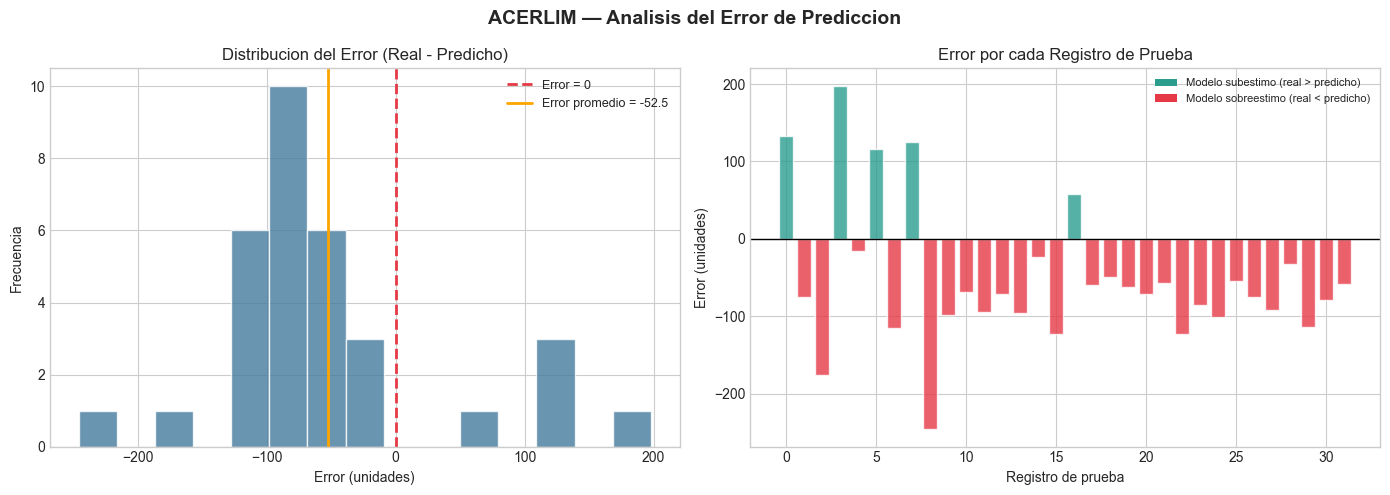

Error promedio          :   -52.53 unidades
Desviacion del error    :    89.45 unidades
Error maximo positivo   :   197.98 unidades (subestimacion)
Error maximo negativo   :  -245.87 unidades (sobreestimacion)


In [ ]:
# ── GRAFICO 4: Distribucion del Error de Prediccion ─────────
errores = Y_prueba.values - predicciones_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ACERLIM — Analisis del Error de Prediccion',
             fontsize=14, fontweight='bold')

# Histograma de errores
axes[0].hist(errores, bins=15, color='#457B9D', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='#E63946', linestyle='--', linewidth=2, label='Error = 0')
axes[0].axvline(x=np.mean(errores), color='orange', linestyle='-',
                linewidth=2, label=f'Error promedio = {np.mean(errores):.1f}')
axes[0].set_title('Distribucion del Error (Real - Predicho)')
axes[0].set_xlabel('Error (unidades)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Errores en secuencia
axes[1].bar(range(len(errores)), errores,
            color=['#E63946' if e < 0 else '#2A9D8F' for e in errores],
            alpha=0.8, edgecolor='white')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Error por cada Registro de Prueba')
axes[1].set_xlabel('Registro de prueba')
axes[1].set_ylabel('Error (unidades)')

# Leyenda
from matplotlib.patches import Patch
leyenda_err = [Patch(facecolor='#2A9D8F', label='Modelo subestimo (real > predicho)'),
               Patch(facecolor='#E63946', label='Modelo sobreestimo (real < predicho)')]
axes[1].legend(handles=leyenda_err, fontsize=8, loc='best')

plt.tight_layout()
plt.savefig('grafico_analisis_error.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Error promedio          : {np.mean(errores):>8.2f} unidades")
print(f"Desviacion del error    : {np.std(errores):>8.2f} unidades")
print(f"Error maximo positivo   : {np.max(errores):>8.2f} unidades (subestimacion)")
print(f"Error maximo negativo   : {np.min(errores):>8.2f} unidades (sobreestimacion)")


---
## SECCIÓN 8 — Reportes y Análisis de Demanda por Temporadas

Visualizaciones interactivas y estáticas para entender patrones de compra:
- ¿Cuáles son los tipos de calamina más solicitados?
- ¿En qué temporada o mes se concentra la mayor cantidad de pedidos?


In [1]:
# ── 1. Tipos de Calamina más solicitados (Gráfico de Pastel interactivo) ──
demanda_por_tipo = df_mensual.groupby('tipo_calamina')['demanda_total'].sum().reset_index()
fig = px.pie(
    demanda_por_tipo, 
    values='demanda_total', 
    names='tipo_calamina', 
    title='Distribución de la Demanda Total por Tipo de Calamina',
    hole=0.3,
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

NameError: name 'df_mensual' is not defined

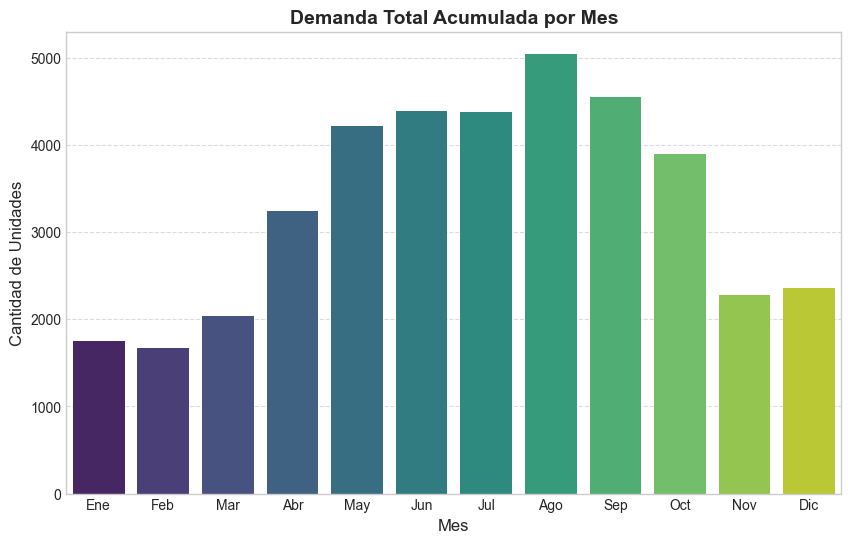

In [ ]:
# ── 2. Distribución Mensual de Demanda (Gráfico de Barras) ──
demanda_por_mes = df_mensual.groupby('mes')['demanda_total'].sum().reset_index()
# Asignar nombres de los meses en español
meses_es = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}
demanda_por_mes['mes_nombre'] = demanda_por_mes['mes'].map(meses_es)

plt.figure(figsize=(10, 6))
sns.barplot(data=demanda_por_mes, x='mes_nombre', y='demanda_total', palette='viridis', order=meses_es.values())
plt.title('Demanda Total Acumulada por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Unidades', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ── 3. KPIs de Temporadas y Tipos más solicitados ──
top_calamina = demanda_por_tipo.sort_values(by='demanda_total', ascending=False).iloc[0]
top_mes = demanda_por_mes.sort_values(by='demanda_total', ascending=False).iloc[0]

demanda_por_temporada = df_mensual.groupby('temporada')['demanda_total'].sum().reset_index()
top_temporada = demanda_por_temporada.sort_values(by='demanda_total', ascending=False).iloc[0]

print("===================================================")
print("                KPIs DE DEMANDA Y TEMPORALIDAD       ")
print("===================================================")
print(f" PRODUCTO ESTRELLA: {top_calamina['tipo_calamina']} ({top_calamina['demanda_total']:.0f} unidades vendidas en total)")
print(f"MES DE MAYOR DEMANDA: {top_mes['mes_nombre']} ({top_mes['demanda_total']:.0f} unidades acumuladas historicas)")
print(f" TEMPORADA DE MAYOR ACTIVIDAD: {top_temporada['temporada']} ({top_temporada['demanda_total']:.0f} unidades despachadas)")
print("===================================================")

                KPIs DE DEMANDA Y TEMPORALIDAD       
 PRODUCTO ESTRELLA: Calamina Trapezoidal (23220 unidades vendidas en total)
MES DE MAYOR DEMANDA: Ago (5045 unidades acumuladas historicas)
 TEMPORADA DE MAYOR ACTIVIDAD: Alta (29695 unidades despachadas)
